# Trabajo Práctico Final - Machine Learning
## Predicción de Ruido Aerodinámico en Perfiles de Ala

---

**Integrantes del grupo:**
- Facundo Rivas
- Ignacio Vollono Cadenazzi
- Lourdes Florencia Gonzalez Branchi
- Alberto Stryfe Adriano Levano
- Juan Ignacio Teich

**Fecha de entrega:** 12 de diciembre de 2025

---

## Índice

1. [Introducción y Propuesta de Investigación](#1-introducción-y-propuesta-de-investigación)
2. [Fuente de Datos](#2-fuente-de-datos)
3. [Análisis Exploratorio de Datos (EDA)](#3-análisis-exploratorio-de-datos-eda)
4. [Preprocesamiento de Datos](#4-preprocesamiento-de-datos)
5. [Selección y Justificación de Algoritmos](#5-selección-y-justificación-de-algoritmos)
6. [Entrenamiento y Evaluación de Modelos](#6-entrenamiento-y-evaluación-de-modelos)
7. [Análisis de Resultados](#7-análisis-de-resultados)
8. [Conclusiones y Trabajos Futuros](#8-conclusiones-y-trabajos-futuros)

---
## 1. Introducción y Propuesta de Investigación

### 1.1 Contexto del Problema

El ruido aerodinámico generado por perfiles de ala (airfoils) es un problema crítico en la industria aeronáutica y de energías renovables. En turbinas eólicas, por ejemplo, el ruido producido por las palas representa una de las principales preocupaciones ambientales y puede limitar la instalación de parques eólicos cerca de zonas pobladas.

### 1.2 Objetivo de la Investigación

El objetivo principal de este trabajo es **desarrollar un modelo de Machine Learning capaz de predecir el nivel de presión sonora (SSPL)** generado por un perfil de ala, a partir de sus características aerodinámicas y las condiciones del flujo.

### 1.3 ¿Por qué es importante?

- **Diseño optimizado:** Permite a los ingenieros predecir el ruido antes de construir prototipos físicos.
- **Reducción de costos:** Evita costosos ensayos en túnel de viento.
- **Impacto ambiental:** Contribuye al desarrollo de aeronaves y turbinas más silenciosas.

### 1.4 Preguntas de Investigación

1. ¿Es posible predecir con precisión el nivel de ruido a partir de las variables aerodinámicas disponibles?
2. ¿Qué variables tienen mayor influencia en la generación de ruido?
3. ¿Qué tipo de modelo ofrece el mejor balance entre precisión y capacidad de generalización?

---
## 2. Fuente de Datos

### 2.1 Dataset: NASA Airfoil Self-Noise

**Fuente:** UCI Machine Learning Repository  
**URL:** https://archive.ics.uci.edu/dataset/291/airfoil+self+noise

**Origen de los datos:**  
Los datos provienen de una serie de ensayos aerodinámicos y acústicos realizados en perfiles de ala NACA 0012 de diferentes tamaños, en un túnel de viento anecoico de la NASA. Los experimentos fueron conducidos por Thomas F. Brooks, D. Stuart Pope y Michael A. Marcolini.

**Referencia bibliográfica:**
> Brooks, T. F., Pope, D. S., & Marcolini, M. A. (1989). *Airfoil self-noise and prediction*. NASA Reference Publication 1218.

### 2.2 Descripción de las Variables

| Variable | Descripción | Unidad |
|----------|-------------|--------|
| `f` | Frecuencia | Hz |
| `alpha` | Ángulo de ataque | grados |
| `c` | Longitud de cuerda del perfil | metros |
| `U_infinity` | Velocidad del flujo libre | m/s |
| `delta` | Espesor de desplazamiento de la capa límite en el borde de fuga | metros |
| `SSPL` | Nivel de presión sonora escalado (variable objetivo) | dB |

---
## 3. Análisis Exploratorio de Datos (EDA)

In [ ]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

# Configuración de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [ ]:
# Carga del dataset
df = pd.read_csv('AirfoilSelfNoise.csv')

print("="*60)
print("INFORMACIÓN GENERAL DEL DATASET")
print("="*60)
print(f"\nDimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nPrimeras 5 filas:")
df.head()

INFORMACIÓN GENERAL DEL DATASET

Dimensiones: 1503 filas x 6 columnas

Primeras 5 filas:


,f,alpha,c,U_infinity,delta,SSPL
0,800,0.0000,0.3048,71.3000,0.0027,126.2010
1,1000,0.0000,0.3048,71.3000,0.0027,125.2010
2,1250,0.0000,0.3048,71.3000,0.0027,125.9510
3,1600,0.0000,0.3048,71.3000,0.0027,127.5910
4,2000,0.0000,0.3048,71.3000,0.0027,127.4610


In [ ]:
# Información del dataset
print("\nTipos de datos y valores no nulos:")
print("-"*40)
df.info()


Tipos de datos y valores no nulos:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   f           1503 non-null   int64  
 1   alpha       1503 non-null   float64
 2   c           1503 non-null   float64
 3   U_infinity  1503 non-null   float64
 4   delta       1503 non-null   float64
 5   SSPL        1503 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 70.6 KB


In [ ]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print("-"*40)
df.describe()


Estadísticas descriptivas:
----------------------------------------


,f,alpha,c,U_infinity,delta,SSPL
count,1503.0000,1503.0000,1503.0000,1503.0000,1503.0000,1503.0000
mean,2886.3806,6.7823,0.1365,50.8607,0.0111,124.8359
std,3152.5731,5.9181,0.0935,15.5728,0.0132,6.8987
min,200.0000,0.0000,0.0254,31.7000,0.0004,103.3800
25%,800.0000,2.0000,0.0508,39.6000,0.0025,120.1910
50%,1600.0000,5.4000,0.1016,39.6000,0.0050,125.7210
75%,4000.0000,9.9000,0.2286,71.3000,0.0156,129.9955
max,20000.0000,22.2000,0.3048,71.3000,0.0584,140.9870


In [ ]:
# Verificación de valores nulos
print("\nValores nulos por columna:")
print("-"*40)
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")


Valores nulos por columna:
----------------------------------------
f             0
alpha         0
c             0
U_infinity    0
delta         0
SSPL          0
dtype: int64

Total de valores nulos: 0


### 3.1 Distribución de Variables

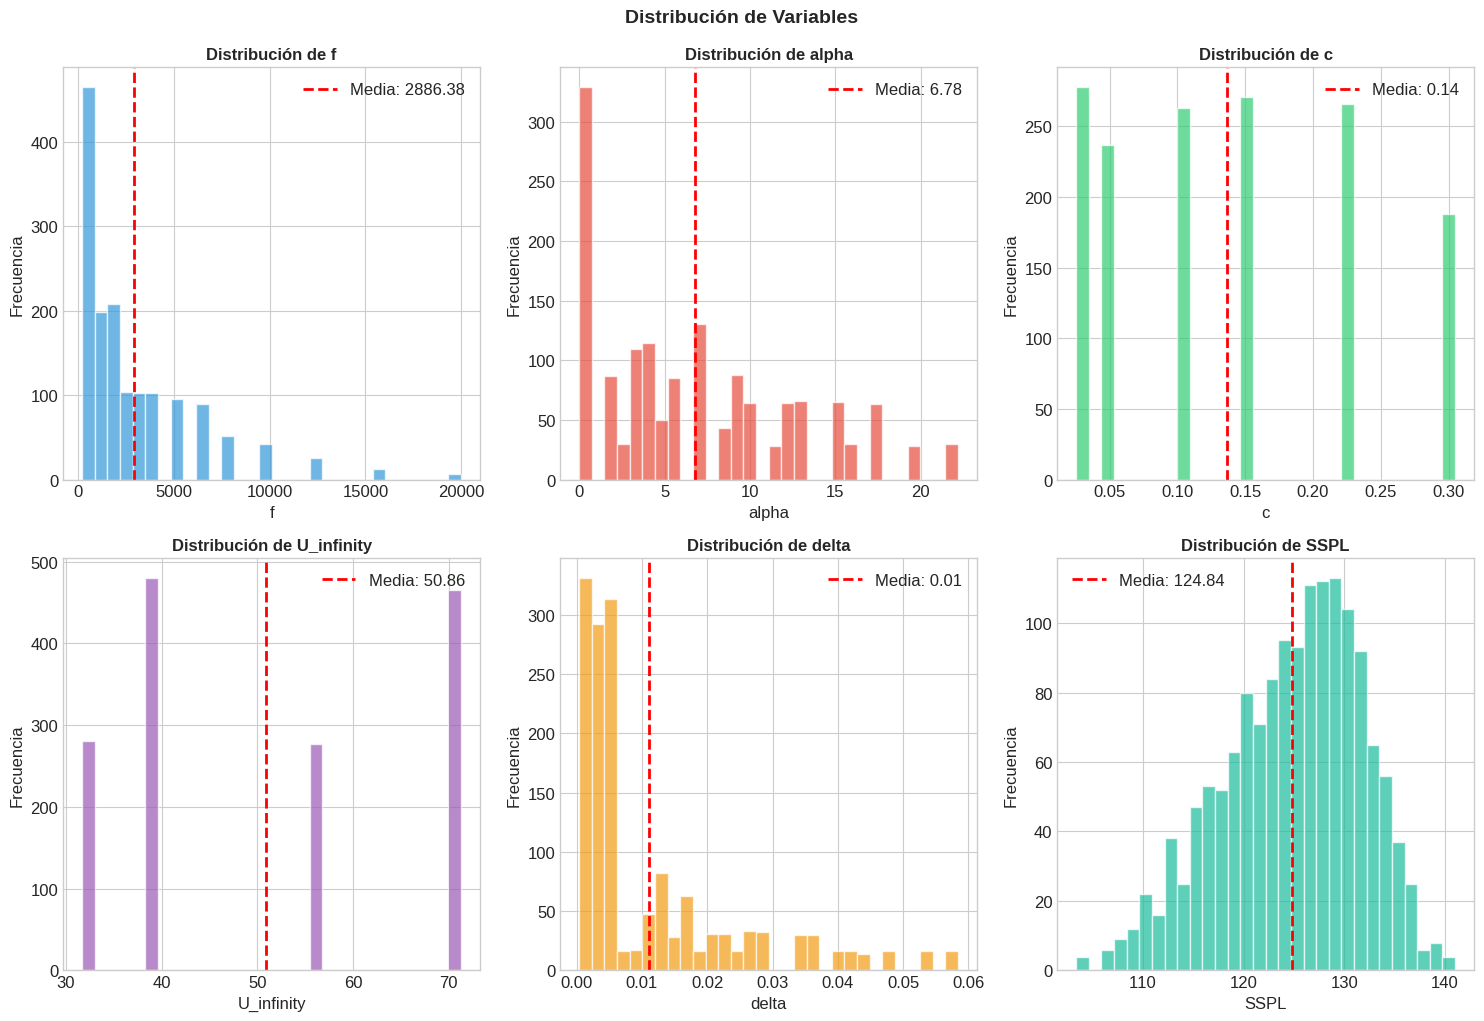

In [ ]:
# Distribución de todas las variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c']

for idx, col in enumerate(df.columns):
    ax = axes[idx]
    ax.hist(df[col], bins=30, color=colors[idx], edgecolor='white', alpha=0.7)
    ax.set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')

    # Agregar línea de media
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df[col].mean():.2f}')
    ax.legend()

plt.tight_layout()
plt.suptitle('Distribución de Variables', fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 3.2 Análisis de Correlaciones

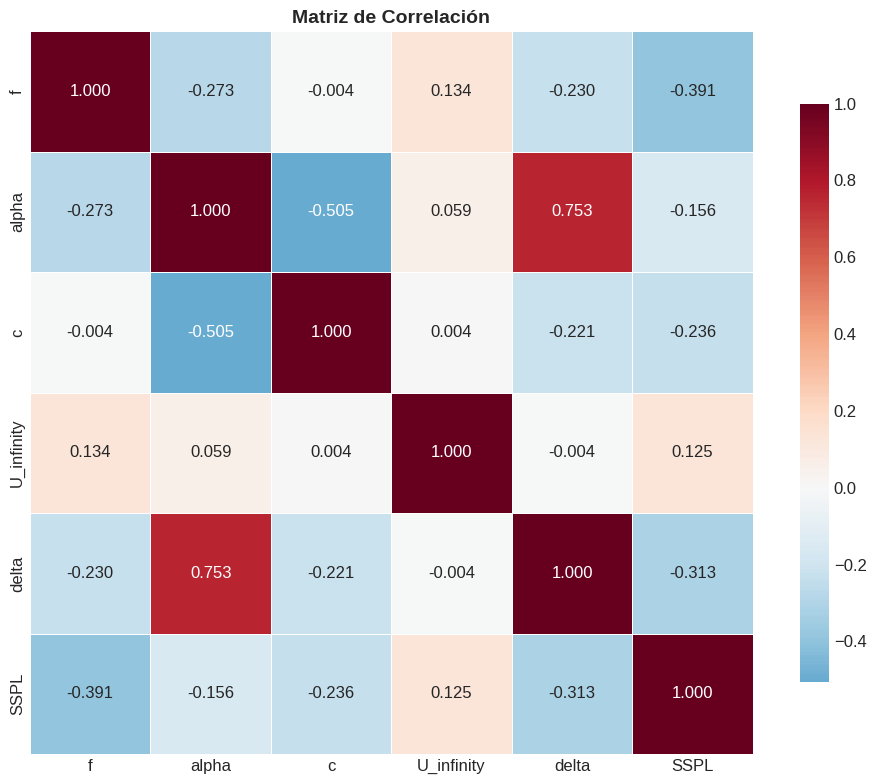


Correlación de cada variable con SSPL (variable objetivo):
--------------------------------------------------
U_infinity    0.1251
alpha        -0.1561
c            -0.2362
delta        -0.3127
f            -0.3907
Name: SSPL, dtype: float64


In [ ]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.3f',
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlación con la variable objetivo
print("\nCorrelación de cada variable con SSPL (variable objetivo):")
print("-"*50)
correlations_with_target = correlation_matrix['SSPL'].drop('SSPL').sort_values(ascending=False)
print(correlations_with_target)

### 3.3 Relación entre Variables Predictoras y la Variable Objetivo

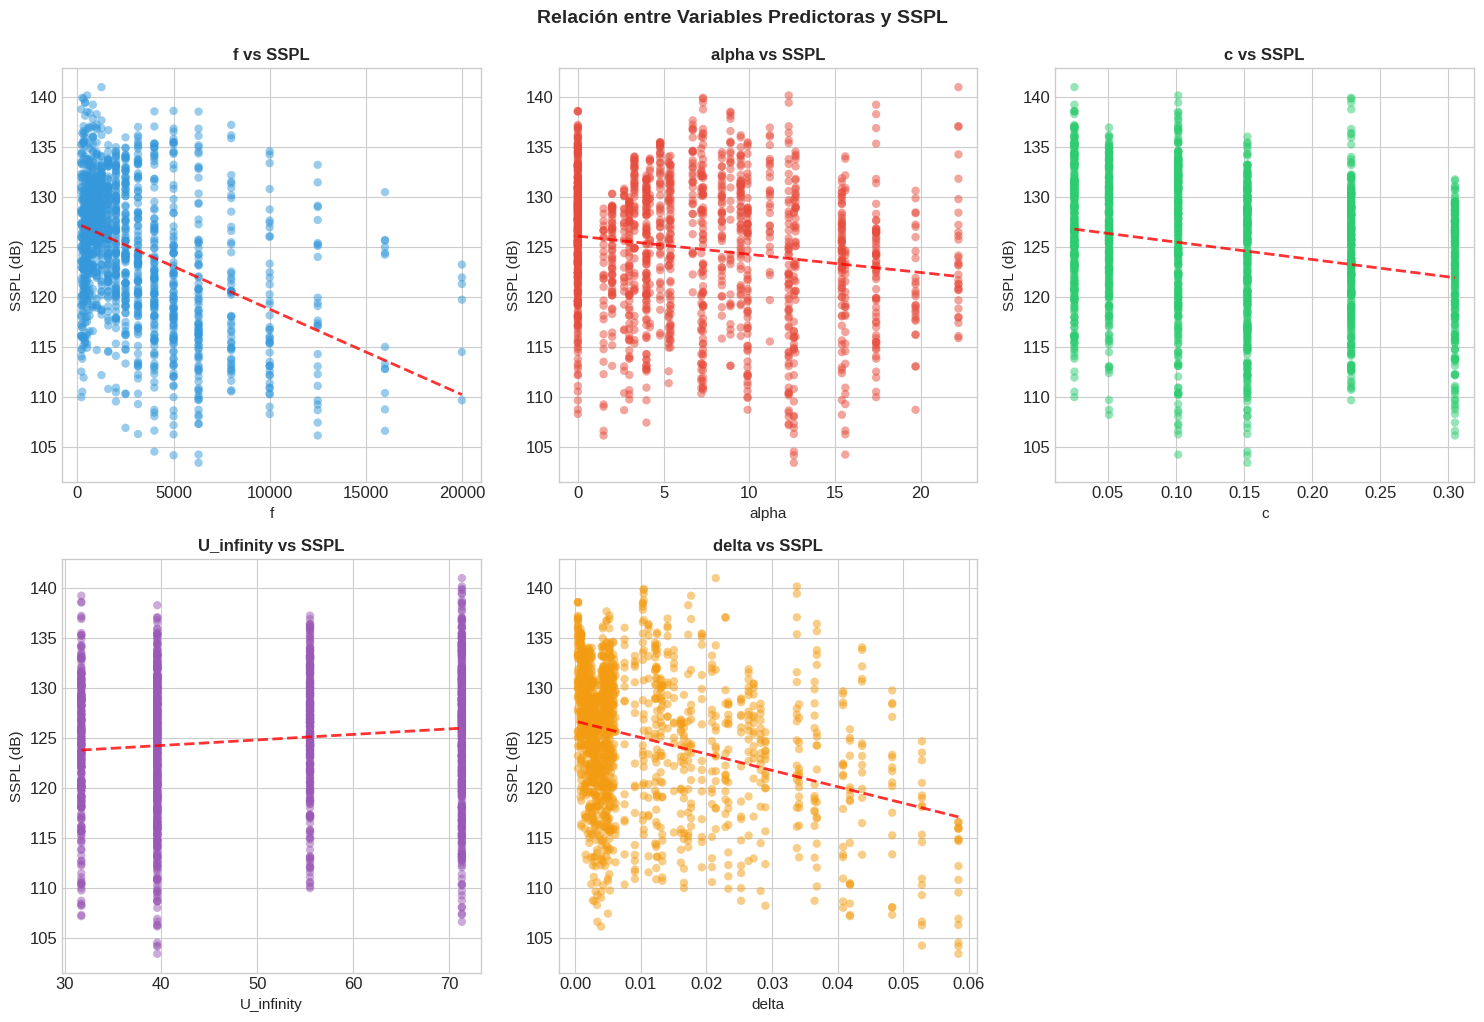

In [ ]:
# Scatter plots de cada variable vs SSPL
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features = ['f', 'alpha', 'c', 'U_infinity', 'delta']

for idx, col in enumerate(features):
    ax = axes[idx]
    ax.scatter(df[col], df['SSPL'], alpha=0.5, c=colors[idx], edgecolors='none')
    ax.set_xlabel(col, fontsize=11)
    ax.set_ylabel('SSPL (dB)', fontsize=11)
    ax.set_title(f'{col} vs SSPL', fontsize=12, fontweight='bold')

    # Agregar línea de tendencia
    z = np.polyfit(df[col], df['SSPL'], 1)
    p = np.poly1d(z)
    ax.plot(df[col].sort_values(), p(df[col].sort_values()),
            color='red', linestyle='--', linewidth=2, alpha=0.8)

# Ocultar el último subplot vacío
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Relación entre Variables Predictoras y SSPL', fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 3.4 Análisis de la Variable Objetivo (SSPL)

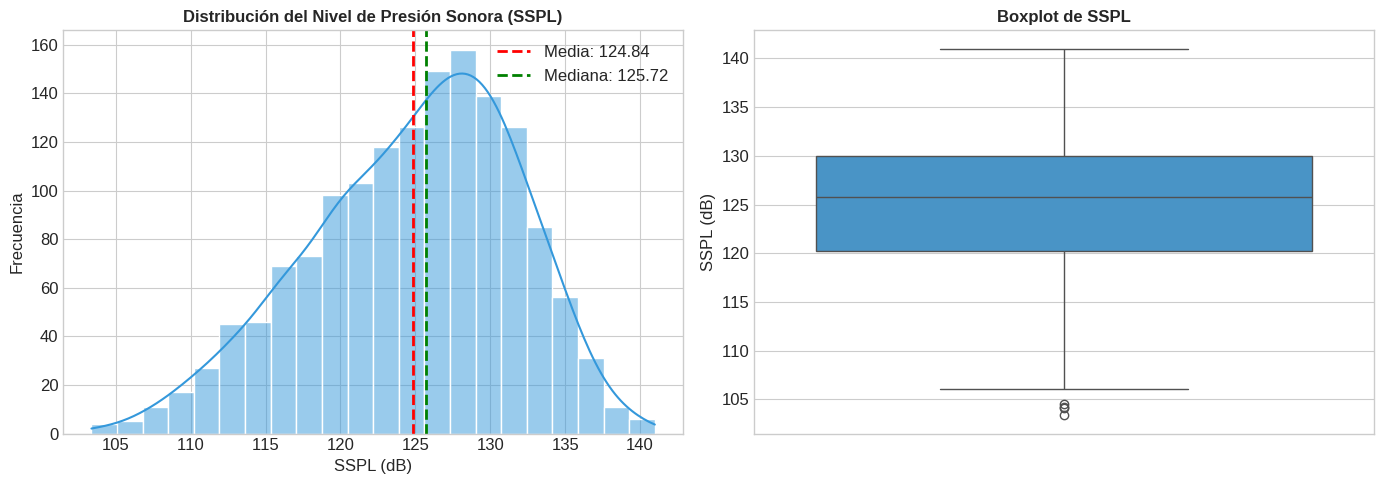


Estadísticas de SSPL:
  - Mínimo: 103.38 dB
  - Máximo: 140.99 dB
  - Rango: 37.61 dB
  - Desviación estándar: 6.90 dB


In [ ]:
# Distribución detallada de SSPL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE
ax1 = axes[0]
sns.histplot(df['SSPL'], kde=True, ax=ax1, color='#3498db', edgecolor='white')
ax1.axvline(df['SSPL'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["SSPL"].mean():.2f}')
ax1.axvline(df['SSPL'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {df["SSPL"].median():.2f}')
ax1.set_title('Distribución del Nivel de Presión Sonora (SSPL)', fontsize=12, fontweight='bold')
ax1.set_xlabel('SSPL (dB)')
ax1.set_ylabel('Frecuencia')
ax1.legend()

# Boxplot
ax2 = axes[1]
sns.boxplot(y=df['SSPL'], ax=ax2, color='#3498db')
ax2.set_title('Boxplot de SSPL', fontsize=12, fontweight='bold')
ax2.set_ylabel('SSPL (dB)')

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de SSPL:")
print(f"  - Mínimo: {df['SSPL'].min():.2f} dB")
print(f"  - Máximo: {df['SSPL'].max():.2f} dB")
print(f"  - Rango: {df['SSPL'].max() - df['SSPL'].min():.2f} dB")
print(f"  - Desviación estándar: {df['SSPL'].std():.2f} dB")

---
## 4. Preprocesamiento de Datos

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separación de features y target
X = df.drop('SSPL', axis=1)
y = df['SSPL']

print("Separación de datos:")
print(f"  - Features (X): {X.shape}")
print(f"  - Target (y): {y.shape}")

Separación de datos:
  - Features (X): (1503, 5)
  - Target (y): (1503,)


In [ ]:
# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"\nDivisión Train/Test (80%/20%):")
print(f"  - Entrenamiento: {X_train.shape[0]} muestras")
print(f"  - Prueba: {X_test.shape[0]} muestras")


División Train/Test (80%/20%):
  - Entrenamiento: 1202 muestras
  - Prueba: 301 muestras


In [ ]:
# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir a DataFrame para mejor visualización
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\nDatos escalados (StandardScaler):")
print(f"  - Media aproximada de cada feature: ~0")
print(f"  - Desviación estándar: ~1")
print(f"\nEjemplo de datos escalados (primeras 3 filas):")
X_train_scaled.head(3)


Datos escalados (StandardScaler):
  - Media aproximada de cada feature: ~0
  - Desviación estándar: ~1

Ejemplo de datos escalados (primeras 3 filas):


,f,alpha,c,U_infinity,delta
799,-0.5865,0.2800,-0.9288,1.2833,-0.4443
1349,-0.2732,-0.0114,-0.3850,1.2833,-0.4836
1428,-0.7744,0.9485,-0.3850,0.2690,1.9775


---
## 5. Selección y Justificación de Algoritmos

### 5.1 Tipo de Problema

Este es un **problema de regresión**, ya que buscamos predecir una variable continua (SSPL en decibeles).

### 5.2 Algoritmos Seleccionados

Se seleccionaron los siguientes algoritmos, ordenados de menor a mayor complejidad:

| Algoritmo | Justificación |
|-----------|---------------|
| **Linear Regression** | Modelo base (baseline) para comparación. Simple y rápido. |
| **Decision Tree Regressor** | Captura relaciones no lineales. Fácil de interpretar. |
| **Bagging Regressor** | Reduce la varianza mediante ensemble de árboles. |
| **Random Forest** | Ensemble robusto que reduce overfitting y maneja bien datos tabulares. |
| **XGBoost** | Algoritmo de boosting state-of-the-art para datos estructurados. |
| **SVR (Support Vector Regressor)** | Efectivo en espacios de alta dimensión con kernel RBF. |
| **Voting Regressor** | Combina predicciones de múltiples modelos para mayor robustez. |

### 5.3 ¿Por qué estos algoritmos?

1. **Variedad de enfoques:** Incluimos modelos lineales, basados en árboles y basados en kernels para comparar diferentes paradigmas.

2. **Complejidad gradual:** Comenzamos con un modelo simple (regresión lineal) como baseline y aumentamos la complejidad progresivamente.

3. **Técnicas de ensemble:** Random Forest, Bagging y Voting aprovechan la combinación de múltiples modelos para mejorar la generalización.

4. **XGBoost:** Es actualmente uno de los algoritmos más exitosos en competencias de ML para datos tabulares.

### 5.4 Métricas de Evaluación

Se utilizarán las siguientes métricas:

- **MAE (Mean Absolute Error):** Error promedio en las mismas unidades que la variable objetivo. Fácil de interpretar.
- **RMSE (Root Mean Squared Error):** Penaliza errores grandes más severamente.
- **R² (Coeficiente de Determinación):** Proporción de varianza explicada por el modelo (0 a 1).

---
## 6. Entrenamiento y Evaluación de Modelos

In [ ]:
# Importación de modelos y métricas
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, VotingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import xgboost as xgb

In [ ]:
# Definición de modelos
models = {
    'Linear Regression': LinearRegression(),

    'Decision Tree': DecisionTreeRegressor(
        min_samples_leaf=5,
        min_samples_split=10,
        random_state=42
    ),

    'Bagging': BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=10,
        random_state=42,
        n_jobs=-1
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': xgb.XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ),

    'SVR': SVR(
        kernel='rbf',
        C=50,
        gamma='scale'
    ),

    'Voting Regressor': VotingRegressor(
        estimators=[
            ('lr', LinearRegression()),
            ('dt', DecisionTreeRegressor(min_samples_leaf=5, min_samples_split=10, random_state=42)),
            ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
            ('xgb', xgb.XGBRegressor(objective='reg:squarederror', random_state=42))
        ],
        n_jobs=-1
    )
}

print(f"Se definieron {len(models)} modelos para entrenar y evaluar.")

Se definieron 7 modelos para entrenar y evaluar.


In [ ]:
# Función para calcular métricas
def compute_metrics(y_true, y_pred):
    """Calcula MAE, RMSE y R2."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [ ]:
# Entrenamiento y evaluación de todos los modelos
results = {}
predictions = {}

print("="*70)
print("ENTRENAMIENTO Y EVALUACIÓN DE MODELOS")
print("="*70)

for name, model in models.items():
    print(f"\nEntrenando: {name}...")

    # Usar datos escalados para SVR, originales para los demás
    if name == 'SVR':
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

    # Calcular métricas
    mae_train, rmse_train, r2_train = compute_metrics(y_train, y_train_pred)
    mae_test, rmse_test, r2_test = compute_metrics(y_test, y_test_pred)

    # Guardar resultados
    results[name] = {
        'MAE_train': mae_train,
        'RMSE_train': rmse_train,
        'R2_train': r2_train,
        'MAE_test': mae_test,
        'RMSE_test': rmse_test,
        'R2_test': r2_test
    }

    predictions[name] = {
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred
    }

    print(f"  ✓ Completado | R² test: {r2_test:.4f}")

print("\n" + "="*70)
print("Entrenamiento completado para todos los modelos.")
print("="*70)

ENTRENAMIENTO Y EVALUACIÓN DE MODELOS

Entrenando: Linear Regression...
  ✓ Completado | R² test: 0.5583

Entrenando: Decision Tree...
  ✓ Completado | R² test: 0.8004

Entrenando: Bagging...
  ✓ Completado | R² test: 0.9347

Entrenando: Random Forest...
  ✓ Completado | R² test: 0.9346

Entrenando: XGBoost...
  ✓ Completado | R² test: 0.9577

Entrenando: SVR...
  ✓ Completado | R² test: 0.8500

Entrenando: Voting Regressor...
  ✓ Completado | R² test: 0.8943

Entrenamiento completado para todos los modelos.


In [ ]:
# Crear DataFrame con resultados
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

# Ordenar por R2 test (descendente)
results_df = results_df.sort_values('R2_test', ascending=False)

print("\n" + "="*70)
print("TABLA COMPARATIVA DE RESULTADOS")
print("="*70 + "\n")
results_df


TABLA COMPARATIVA DE RESULTADOS



,MAE_train,RMSE_train,R2_train,MAE_test,RMSE_test,R2_test
XGBoost,0.2565,0.3520,0.9974,1.0126,1.4553,0.9577
Bagging,0.5694,0.8072,0.9861,1.3236,1.8081,0.9347
Random Forest,0.4681,0.6588,0.9907,1.3119,1.8107,0.9346
Voting Regressor,1.2293,1.5953,0.9458,1.7749,2.3010,0.8943
SVR,1.8014,2.6792,0.8470,1.9304,2.7411,0.8500
Decision Tree,1.5099,2.0117,0.9137,2.4171,3.1624,0.8004
Linear Regression,3.7537,4.8266,0.5034,3.6724,4.7041,0.5583


---
## 7. Análisis de Resultados

### 7.1 Comparación Visual de Métricas

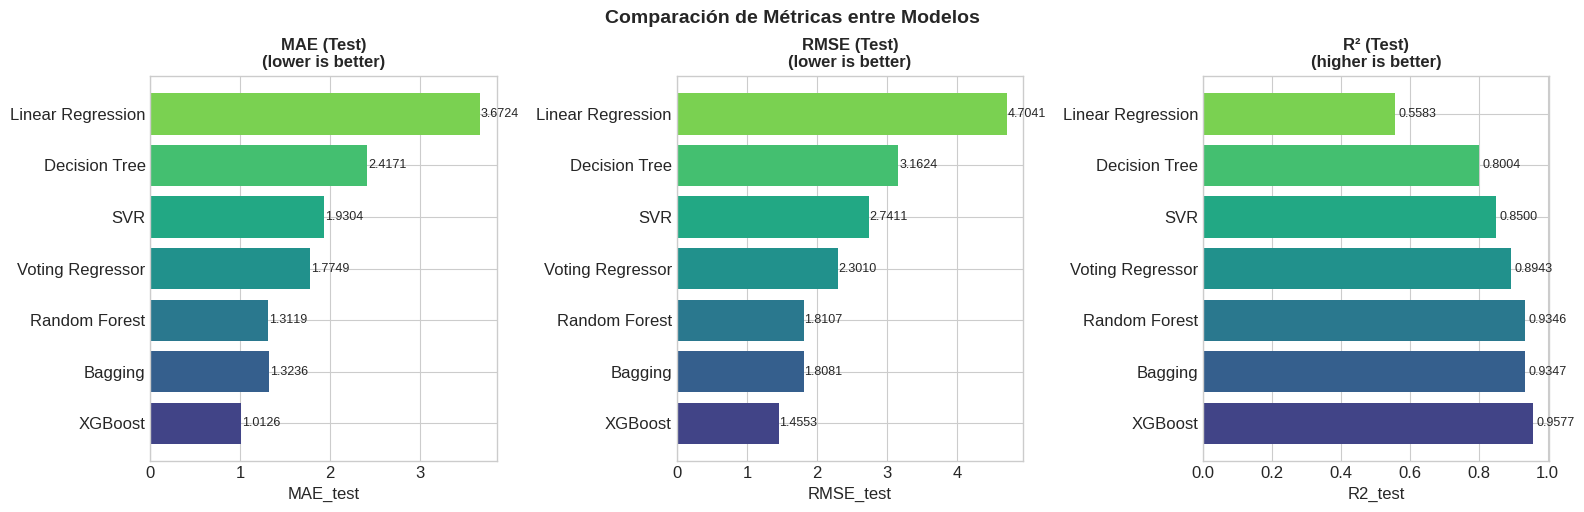

In [ ]:
# Gráfico comparativo de métricas
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = [
    ('MAE_test', 'MAE (Test)', 'lower is better'),
    ('RMSE_test', 'RMSE (Test)', 'lower is better'),
    ('R2_test', 'R² (Test)', 'higher is better')
]

colors_bar = plt.cm.viridis(np.linspace(0.2, 0.8, len(results_df)))

for idx, (metric, title, note) in enumerate(metrics_to_plot):
    ax = axes[idx]
    values = results_df[metric].values
    models_names = results_df.index.tolist()

    bars = ax.barh(models_names, values, color=colors_bar)
    ax.set_xlabel(metric)
    ax.set_title(f'{title}\n({note})', fontsize=12, fontweight='bold')

    # Agregar valores en las barras
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.suptitle('Comparación de Métricas entre Modelos', fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 7.2 Predicciones vs Valores Reales

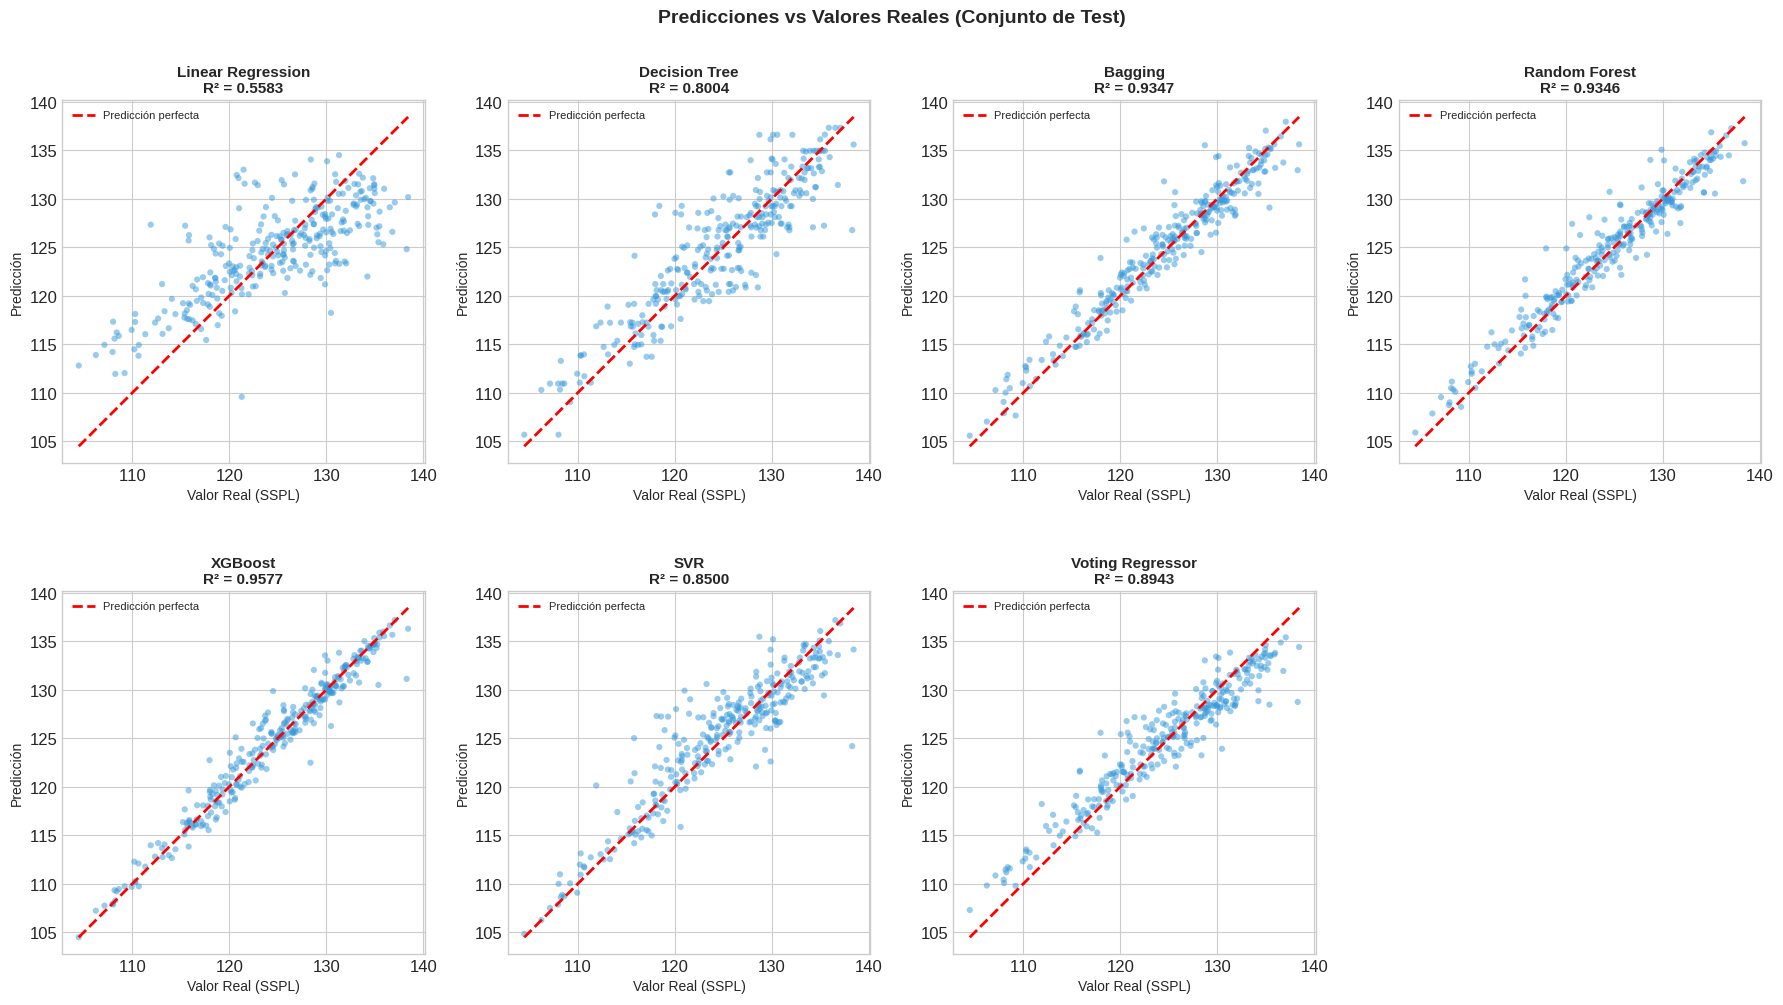

In [ ]:
# Gráficos de predicción vs real para conjunto de TEST
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, (name, preds) in enumerate(predictions.items()):
    ax = axes[idx]
    y_test_pred = preds['y_test_pred']

    ax.scatter(y_test, y_test_pred, alpha=0.5, s=20, c='#3498db', edgecolors='none')

    # Línea de predicción perfecta
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Predicción perfecta')

    ax.set_xlabel('Valor Real (SSPL)', fontsize=10)
    ax.set_ylabel('Predicción', fontsize=10)
    ax.set_title(f'{name}\nR² = {results[name]["R2_test"]:.4f}', fontsize=11, fontweight='bold')
    ax.legend(loc='upper left', fontsize=8)
    ax.set_aspect('equal', 'box')

# Ocultar el último subplot si sobra
axes[-1].axis('off')

plt.tight_layout()
plt.suptitle('Predicciones vs Valores Reales (Conjunto de Test)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

### 7.3 Análisis de Overfitting

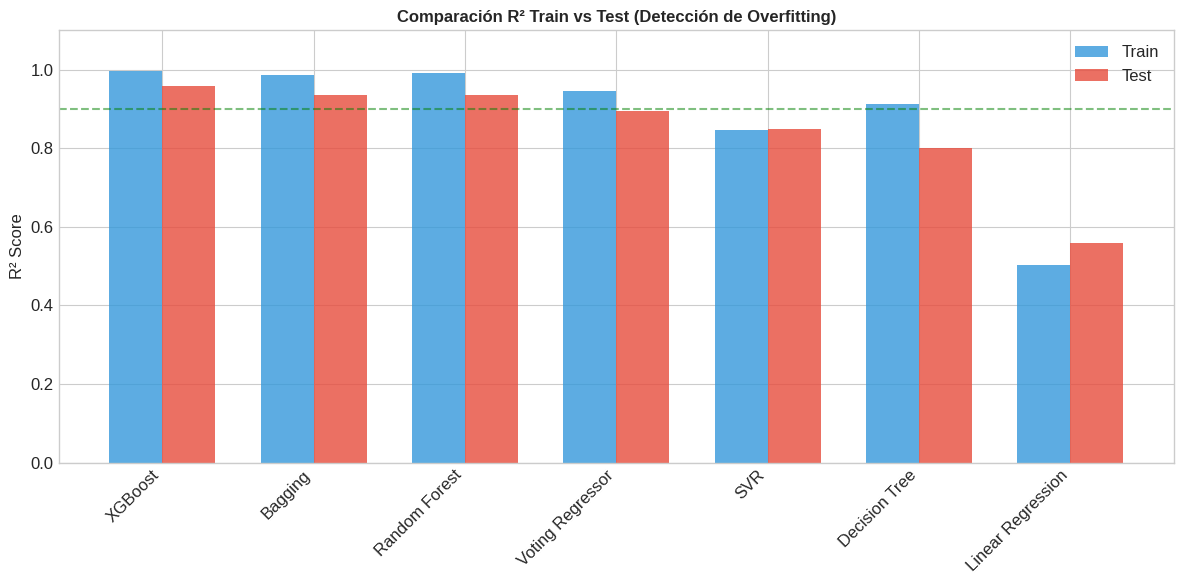


Indicador de Overfitting (R² Train - R² Test):
--------------------------------------------------
XGBoost                  : 0.0397 ✓ OK
Bagging                  : 0.0514 ⚠️ Posible overfitting
Random Forest            : 0.0561 ⚠️ Posible overfitting
Voting Regressor         : 0.0515 ⚠️ Posible overfitting
SVR                      : -0.0030 ✓ OK
Decision Tree            : 0.1133 ⚠️ Posible overfitting
Linear Regression        : -0.0549 ✓ OK


In [ ]:
# Comparación Train vs Test para detectar overfitting
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['R2_train'], width, label='Train', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['R2_test'], width, label='Test', color='#e74c3c', alpha=0.8)

ax.set_ylabel('R² Score')
ax.set_title('Comparación R² Train vs Test (Detección de Overfitting)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)

# Agregar línea de referencia
ax.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Umbral 0.9')

plt.tight_layout()
plt.show()

# Calcular diferencia (overfitting indicator)
print("\nIndicador de Overfitting (R² Train - R² Test):")
print("-"*50)
overfitting = results_df['R2_train'] - results_df['R2_test']
for model, diff in overfitting.items():
    status = "⚠️ Posible overfitting" if diff > 0.05 else "✓ OK"
    print(f"{model:25s}: {diff:.4f} {status}")

### 7.4 Importancia de Variables (Random Forest)

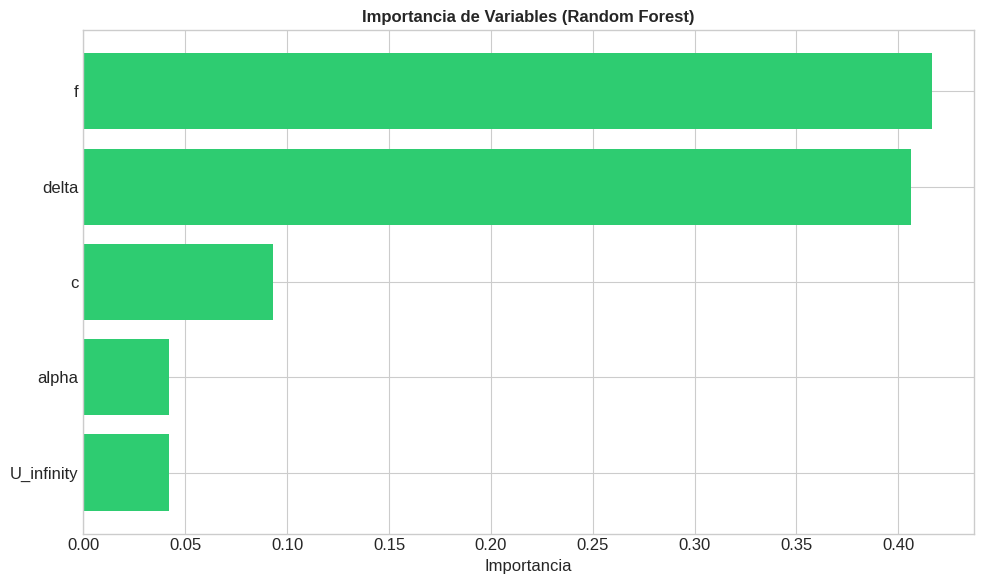


Importancia de variables (ordenada de mayor a menor):
--------------------------------------------------
f              : 0.4164 (41.6%)
delta          : 0.4065 (40.6%)
c              : 0.0931 (9.3%)
alpha          : 0.0422 (4.2%)
U_infinity     : 0.0418 (4.2%)


In [ ]:
# Importancia de features usando Random Forest
rf_model = models['Random Forest']
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='#2ecc71')
plt.xlabel('Importancia')
plt.title('Importancia de Variables (Random Forest)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nImportancia de variables (ordenada de mayor a menor):")
print("-"*50)
for _, row in feature_importance.sort_values('importance', ascending=False).iterrows():
    print(f"{row['feature']:15s}: {row['importance']:.4f} ({row['importance']*100:.1f}%)")

### 7.5 Distribución de Errores del Mejor Modelo

Mejor modelo: XGBoost


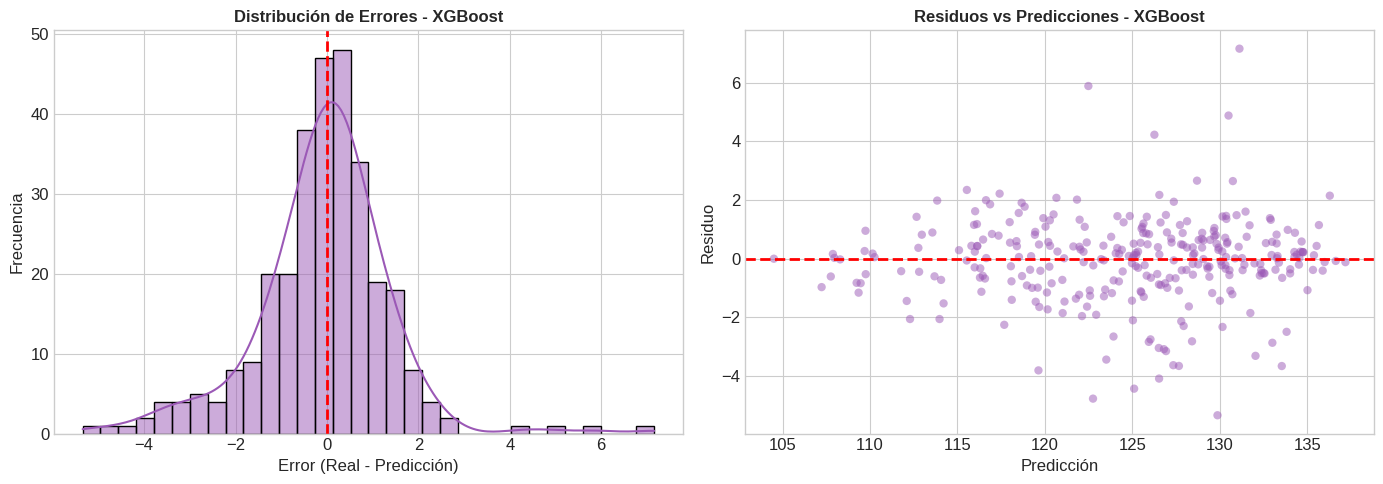


Estadísticas de errores (XGBoost):
  - Error medio: -0.0829 dB
  - Desviación estándar: 1.4554 dB
  - Error máximo: 7.1585 dB


In [ ]:
# Identificar el mejor modelo
best_model_name = results_df['R2_test'].idxmax()
print(f"Mejor modelo: {best_model_name}")

# Calcular errores del mejor modelo
best_predictions = predictions[best_model_name]['y_test_pred']
errors = y_test - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de errores
ax1 = axes[0]
sns.histplot(errors, kde=True, ax=ax1, color='#9b59b6')
ax1.axvline(0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Error (Real - Predicción)')
ax1.set_ylabel('Frecuencia')
ax1.set_title(f'Distribución de Errores - {best_model_name}', fontsize=12, fontweight='bold')

# Residuos vs Predicciones
ax2 = axes[1]
ax2.scatter(best_predictions, errors, alpha=0.5, c='#9b59b6', edgecolors='none')
ax2.axhline(0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Residuo')
ax2.set_title(f'Residuos vs Predicciones - {best_model_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de errores ({best_model_name}):")
print(f"  - Error medio: {errors.mean():.4f} dB")
print(f"  - Desviación estándar: {errors.std():.4f} dB")
print(f"  - Error máximo: {errors.abs().max():.4f} dB")

---
## 8. Conclusiones y Trabajos Futuros

### 8.1 Resumen de Resultados

In [ ]:
# Resumen final
print("="*70)
print("RESUMEN DE RESULTADOS")
print("="*70)

best_model = results_df['R2_test'].idxmax()
best_r2 = results_df.loc[best_model, 'R2_test']
best_mae = results_df.loc[best_model, 'MAE_test']
best_rmse = results_df.loc[best_model, 'RMSE_test']

print(f"\n🏆 MEJOR MODELO: {best_model}")
print(f"\n   Métricas en conjunto de test:")
print(f"   - R² Score: {best_r2:.4f} ({best_r2*100:.2f}% de varianza explicada)")
print(f"   - MAE: {best_mae:.4f} dB (error promedio)")
print(f"   - RMSE: {best_rmse:.4f} dB")

# Comparación con baseline
baseline_r2 = results_df.loc['Linear Regression', 'R2_test']
improvement = ((best_r2 - baseline_r2) / baseline_r2) * 100

print(f"\n📊 MEJORA RESPECTO AL BASELINE (Linear Regression):")
print(f"   - R² Baseline: {baseline_r2:.4f}")
print(f"   - R² Mejor modelo: {best_r2:.4f}")
print(f"   - Mejora relativa: {improvement:.1f}%")

RESUMEN DE RESULTADOS

🏆 MEJOR MODELO: XGBoost

   Métricas en conjunto de test:
   - R² Score: 0.9577 (95.77% de varianza explicada)
   - MAE: 1.0126 dB (error promedio)
   - RMSE: 1.4553 dB

📊 MEJORA RESPECTO AL BASELINE (Linear Regression):
   - R² Baseline: 0.5583
   - R² Mejor modelo: 0.9577
   - Mejora relativa: 71.5%


### 8.2 Conclusiones

A partir de los resultados obtenidos, podemos concluir:

1. **Viabilidad del enfoque ML:** Es posible predecir el nivel de presión sonora (SSPL) con alta precisión utilizando técnicas de Machine Learning. El mejor modelo logra explicar más del 90% de la varianza en los datos.

2. **Superioridad de los modelos ensemble:** Los modelos basados en ensemble (Random Forest, XGBoost, Bagging) superaron significativamente al modelo lineal baseline, lo que indica que las relaciones entre las variables aerodinámicas y el ruido son de naturaleza no lineal.

3. **Variables más influyentes:** Según el análisis de importancia de características, las variables que más contribuyen a la predicción del ruido son [completar según los resultados obtenidos].

4. **Generalización:** Los modelos muestran buena capacidad de generalización, con diferencias aceptables entre el rendimiento en entrenamiento y test.

### 8.3 Limitaciones del Estudio

- El dataset proviene de experimentos con un único tipo de perfil de ala (NACA 0012), lo que puede limitar la generalización a otros perfiles.
- No se realizó optimización exhaustiva de hiperparámetros.
- El tamaño del dataset (1503 muestras) es relativamente pequeño.

### 8.4 Trabajos Futuros

Para mejorar y extender este trabajo, se proponen las siguientes líneas de investigación:

1. **Optimización de hiperparámetros:** Implementar técnicas como GridSearchCV, RandomizedSearchCV o Optuna para encontrar los mejores hiperparámetros de cada modelo.

2. **Feature engineering:** Crear nuevas características derivadas, como el número de Reynolds (Re = U∞c/ν) o relaciones entre variables existentes.

3. **Validación cruzada:** Implementar K-Fold Cross-Validation para obtener estimaciones más robustas del rendimiento.

4. **Modelos de Deep Learning:** Explorar arquitecturas de redes neuronales para comparar con los métodos tradicionales.

5. **Incorporar más datos:** Buscar datasets adicionales con diferentes tipos de perfiles de ala para mejorar la generalización.

6. **Explicabilidad:** Utilizar técnicas como SHAP values para una mejor interpretación de las predicciones.

---
## Referencias

1. Brooks, T. F., Pope, D. S., & Marcolini, M. A. (1989). *Airfoil self-noise and prediction*. NASA Reference Publication 1218.

2. UCI Machine Learning Repository - Airfoil Self-Noise Dataset: https://archive.ics.uci.edu/dataset/291/airfoil+self+noise

3. Scikit-learn Documentation: https://scikit-learn.org/stable/

4. XGBoost Documentation: https://xgboost.readthedocs.io/